In [1]:
# torch
import torch
import torchvision
import torch.nn.functional as F
import torch.nn as nn
from torchvision import transforms as T
from torch.utils.data import DataLoader
from pytorch_lightning.loggers import CSVLogger
from tqdm.notebook import tnrange, tqdm_notebook
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
import pytorch_lightning as pl
from torchvision.transforms.functional import to_pil_image

# standard libraries
from PIL import Image
import matplotlib.pyplot as plt
import math
import random
import os
import json
import cv2
import pandas as pd
import numpy as np
import sys
import json

sys.path.append("../_Segmentation Model/")
sys.path.append("../")

from postprocess import PredictionProcessor
from dataset import TreeDataset
from transforms import MaskResize, InstanceMaskCropper, PadToSizeTensor
from visualize import BatchVisualizer as BV
import utils
import inference_pipeline as ip

from models.resnets import TreeMaskRCNN
from models.trainer import InstanceSegLightningModule

In [2]:
SIZE = (500, 500)
data_configs = {
    'root': '../data/Some Trees Dataset.v12i.coco-segmentation',
    'seed': 42,
    'transforms': {
        'image_transforms': None,
        'mask_transforms': None
    },
    'batch_size': 8
}

In [3]:
utils.set_seed(data_configs['seed'])
train_set = TreeDataset(data_configs['root'], 
                        'train', 
                        data_configs['transforms']['image_transforms'], 
                        data_configs['transforms']['mask_transforms']
)

val_set = TreeDataset(data_configs['root'], 
                        'valid', 
                        data_configs['transforms']['image_transforms'], 
                        data_configs['transforms']['mask_transforms']
)

test_set = TreeDataset(data_configs['root'], 
                        'test', 
                        data_configs['transforms']['image_transforms'], 
                        data_configs['transforms']['mask_transforms']
)

In [4]:
class InstanceMaskCropperNP:
    """
    Crops instances using their masks directly and replaces background with white.

    Modes:
        - 'full' : returns masked image of same size
        - 'crop' : returns masked and tightly cropped image

    Accepts:
        image : numpy array (H, W, 3) or (3, H, W)
        target["masks"] : numpy array (N, H, W) with 0/1 masks
    """

    def __init__(self, mode="crop"):
        assert mode in ["full", "crop"]
        self.mode = mode

    def __call__(self, image, target):
        masks = target["masks"]   # (N, H, W)
        crops = []

        # ---- Handle input layout (HWC vs CHW) ----
        if image.ndim != 3:
            raise ValueError("Image must be shape (H,W,3) or (3,H,W)")

        chw = False
        if image.shape[0] == 3:  # CHW
            chw = True
            image = np.transpose(image, (1, 2, 0))  # → HWC

        H, W, C = image.shape
        white_bg = np.ones_like(image) * 255

        # ---- Process each instance ----
        for i in range(masks.shape[0]):
            mask = masks[i]  # (H, W)
            mask_3 = np.expand_dims(mask, axis=-1)  # (H, W, 1)

            # masked foreground + white background
            masked_img = image * mask_3 + white_bg * (1 - mask_3)

            if self.mode == "full":
                crops.append(masked_img if not chw else np.transpose(masked_img, (2, 0, 1)))
                continue

            # ----- Cropping -----
            ys, xs = np.where(mask > 0)

            if len(ys) == 0 or len(xs) == 0:
                continue

            ymin, ymax = ys.min(), ys.max()
            xmin, xmax = xs.min(), xs.max()

            cropped = masked_img[ymin:ymax+1, xmin:xmax+1, :]

            if chw:
                cropped = np.transpose(cropped, (2, 0, 1))

            crops.append(cropped)

        return crops

In [7]:
ic = InstanceMaskCropperNP()
dest_path = '../data/Cerrado_trees.v1i.coco/_separated2'
for idx, (image, target) in enumerate(tqdm_notebook(train_set)):
    crops = ic(image, target)
    for crown in crops:
        pil_img = Image.fromarray(crown)
        pil_img.save(os.path.join(dest_path, f'{idx}.png'))

  0%|          | 0/2885 [00:00<?, ?it/s]

In [8]:
paths = [
    '../data/Cerrado_trees.v1i.coco/_separated',
    '../data/Cerrado_trees.v1i.coco/_separated2'
]

In [25]:
image_data = {
    'version': [],
    'image_path': [],
    'height': [],
    'width': []
}

for path in paths:
    images = os.listdir(path)
    for image in tqdm_notebook(images):
        image_path = os.path.join(path, image)
        image_arr = cv2.imread(image_path)
        h, w, c = image_arr.shape
        image_data['version'].append(path.split('/')[-1])
        image_data['image_path'].append(image_path)
        image_data['height'].append(h)
        image_data['width'].append(w)

  0%|          | 0/183 [00:00<?, ?it/s]

  0%|          | 0/2885 [00:00<?, ?it/s]

In [27]:
image_df = pd.DataFrame(image_data)

### **Height and Width of Crops**

- Will be used for pad resizing.

array([[<Axes: title={'center': 'height'}>,
        <Axes: title={'center': 'width'}>]], dtype=object)

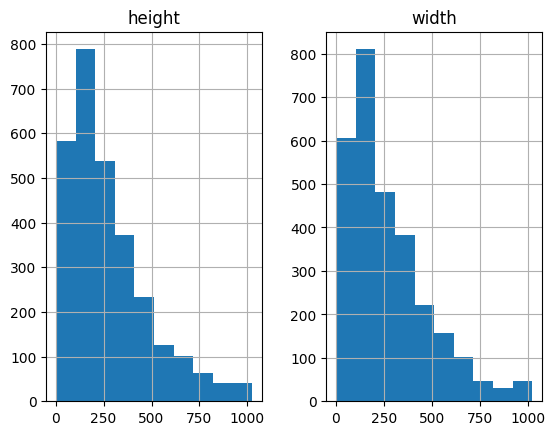

In [32]:
image_df[image_df['version'] == '_separated2'][['height', 'width']].hist()

array([[<Axes: title={'center': 'height'}>,
        <Axes: title={'center': 'width'}>]], dtype=object)

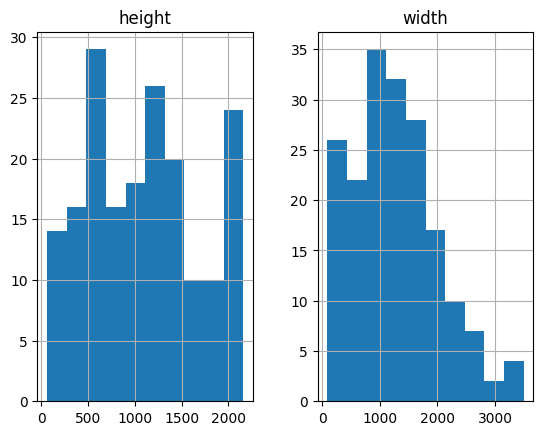

In [33]:
image_df[image_df['version'] == '_separated'][['height', 'width']].hist()

In [34]:
image_df[image_df['version'] == '_separated'][['height', 'width']].describe()

,height,width
count,183.000000,183.000000
mean,1102.256831,1282.207650
std,600.374549,734.908883
min,64.000000,94.000000
25%,596.500000,763.000000
50%,1056.000000,1192.000000
75%,1502.500000,1708.000000
max,2159.000000,3496.000000


In [35]:
image_df[image_df['version'] == '_separated2'][['height', 'width']].describe()

,height,width
count,2885.000000,2885.000000
mean,274.938995,273.164991
std,209.378458,209.324466
min,1.000000,2.000000
25%,118.000000,116.000000
50%,216.000000,213.000000
75%,375.000000,376.000000
max,1024.000000,1024.000000


### **Make a Dataset Class**

- This `Dataset` class should skip small and irregular images (i.e., very rectangle)
- This may be done in the `__init__()` method where it will sanity check and clean the dataset of those noises.